In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from scipy import optimize
from scipy.stats import norm
from matplotlib import cm
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split
#Machinig learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

In [2]:
## cross-validation
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(
        fit_times_mean,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

In [18]:
def data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   ):# Caso mas visible
  ## genara dos distribuciones normales dos varibles
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1



def sample(N1, N2, rv1, rv2, r):
  # genera una muestra aleatoria a partir de las distribuciones rv y genera y como etiquetas de clase
  X_t = np.concatenate([rv1.rvs(N1, random_state = r  ), rv2.rvs(N2,random_state = r)]) # Todos los datos en la misma distribución,
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y





def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy




def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

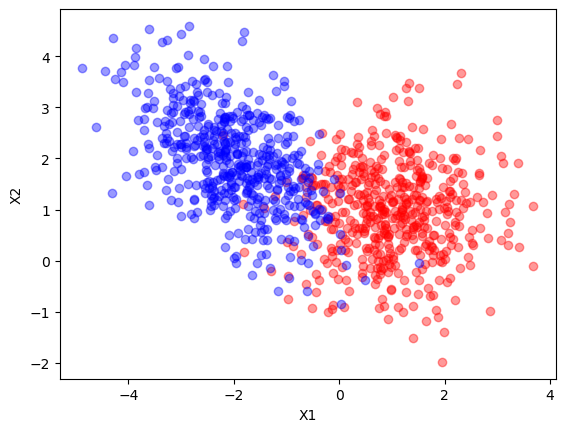

In [6]:
rv1, rv2 = data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   )
X_t, y = sample(500,500, rv1, rv2,10)
plt.plot(X_t[y==0][:,0],X_t[y==0][:,1],"ro", alpha=0.4)
plt.plot(X_t[y==1][:,0],X_t[y==1][:,1],"bo", alpha=0.4)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

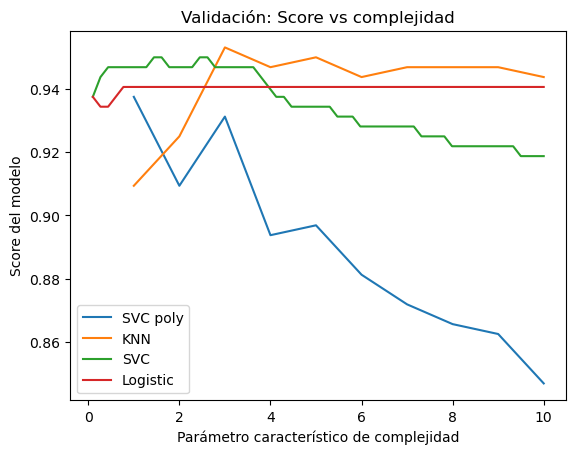

In [24]:



rv1, rv2 = data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   )
X_t, y = sample(500,500, rv1, rv2,10)


X_trainval, X_test, y_trainval, y_test = train_test_split(X_t, y, test_size = 0.2, random_state = 1, stratify = y) 
X_train, X_validation, y_train, y_validation = train_test_split(X_trainval, y_trainval, test_size = 0.4, random_state = 1, stratify = y_trainval)
#X_test = X_test.reshape(-1,1)
#X_validation = X_validation.reshape(-1,1)
#X_train = X_train.reshape(-1,1)



Gammas = np.linspace(0.1, 10, 60)
Scores_svc = []
Scores_logistic = []
for Gamma in Gammas:
    clf = SVC(gamma = Gamma)
    clf.fit(X_train, y_train)  
    Score = clf.score(X_validation,y_validation)
    Scores_svc.append(Score)


for c in Gammas:
    clf = LogisticRegression(C=c)
    clf.fit(X_train, y_train)
    Scores_logistic.append(clf.score(X_validation, y_validation))



Degrees = range(1, 11)  # degree alto en poly se vuelve muy costoso computacionalmente
from sklearn.neighbors import KNeighborsClassifier
Scores_knn = []
for k in Degrees:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    Scores_knn.append(clf.score(X_validation, y_validation))


Scores_poly = []
for d in Degrees:
    clf = SVC(kernel='poly', degree=d)
    clf.fit(X_train, y_train)
    Scores_poly.append(clf.score(X_validation, y_validation))

plt.plot(Degrees, Scores_poly, label='SVC poly')
plt.plot(Degrees, Scores_knn, label = 'KNN')
plt.plot(Gammas, Scores_svc, label = 'SVC')
plt.plot(Gammas, Scores_logistic, label = 'Logistic')
plt.xlabel("Parámetro característico de complejidad")
plt.ylabel("Score del modelo")
plt.title("Validación: Score vs complejidad")
plt.legend()
plt.show()

In [36]:
# Mejores modelos
index_best_knn = np.argmax(Scores_knn)
index_best_svc = np.argmax(Scores_svc)
best_svc = Gammas[index_best_svc]
best_knn = Degrees[index_best_knn]
print(best_svc, best_knn)

1.4423728813559324 3


De la etapa de validación, el mejor modelo fue KNeighborsClassifier con n_neighbors = 3, y el segundo mejor fue SVC con gamma = 1.442372.

In [ ]:
clf_best = KNeighborsClassifier(n_neighbors = best_knn)

2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn.

In [16]:
# Entrenar arbol de desicion
from sklearn.tree import DecisionTreeClassifier
clf_treeclass = DecisionTreeClassifier(max_depth = 1)
X_train_re = X_train.reshape(-1,1)
clf = clf_treeclass.fit(X_train, y_train)


Training error:0.848
Test error: 0.890


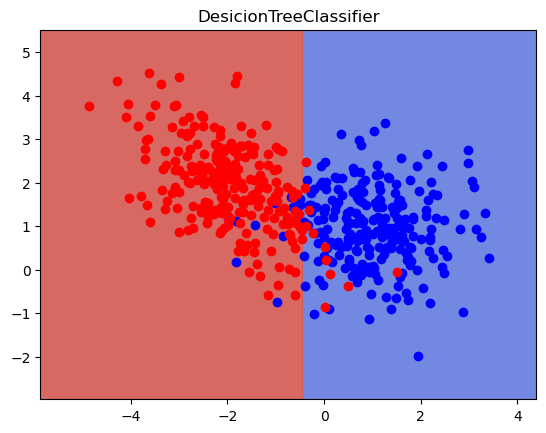

In [38]:
X0, X1 = X_train[:, 0], X_train[:, 1]
fig, ax = plt.subplots()
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf_treeclass, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train[y_train==0][:,0],X_train[y_train==0][:,1],"bo", alpha=1)
plt.plot(X_train[y_train==1][:,0],X_train[y_train==1][:,1],"ro", alpha=1)
plt.title('DesicionTreeClassifier')
print(f"Training error:{clf.score(X_train, y_train):.3f}")
print(f"Test error: {clf.score(X_test, y_test):.3f}" )

Training error:0.956
Test error: 0.975


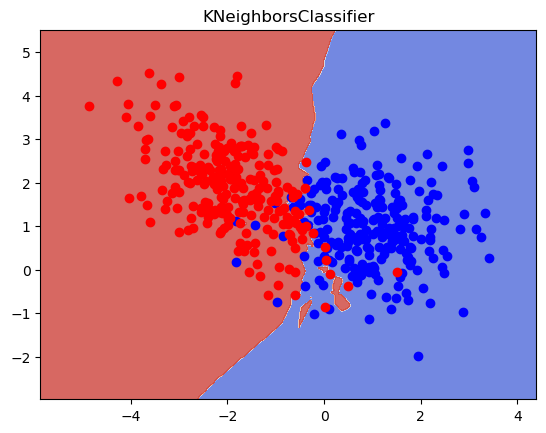

In [39]:
clf_best = KNeighborsClassifier(n_neighbors = best_knn)
clf_best = clf_best.fit(X_train,y_train)

X0, X1 = X_train[:, 0], X_train[:, 1]
fig, ax = plt.subplots()
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf_best, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train[y_train==0][:,0],X_train[y_train==0][:,1],"bo", alpha=1)
plt.plot(X_train[y_train==1][:,0],X_train[y_train==1][:,1],"ro", alpha=1)
plt.title('KNeighborsClassifier')
print(f"Training error:{clf_svc.score(X_train, y_train):.3f}")
print(f"Test error: {clf_svc.score(X_test, y_test):.3f}" )

KNeighbors fue ligeramente superior a DesicionTreeClassifier. A continuación, las curvas de aprendizaje de este primero.

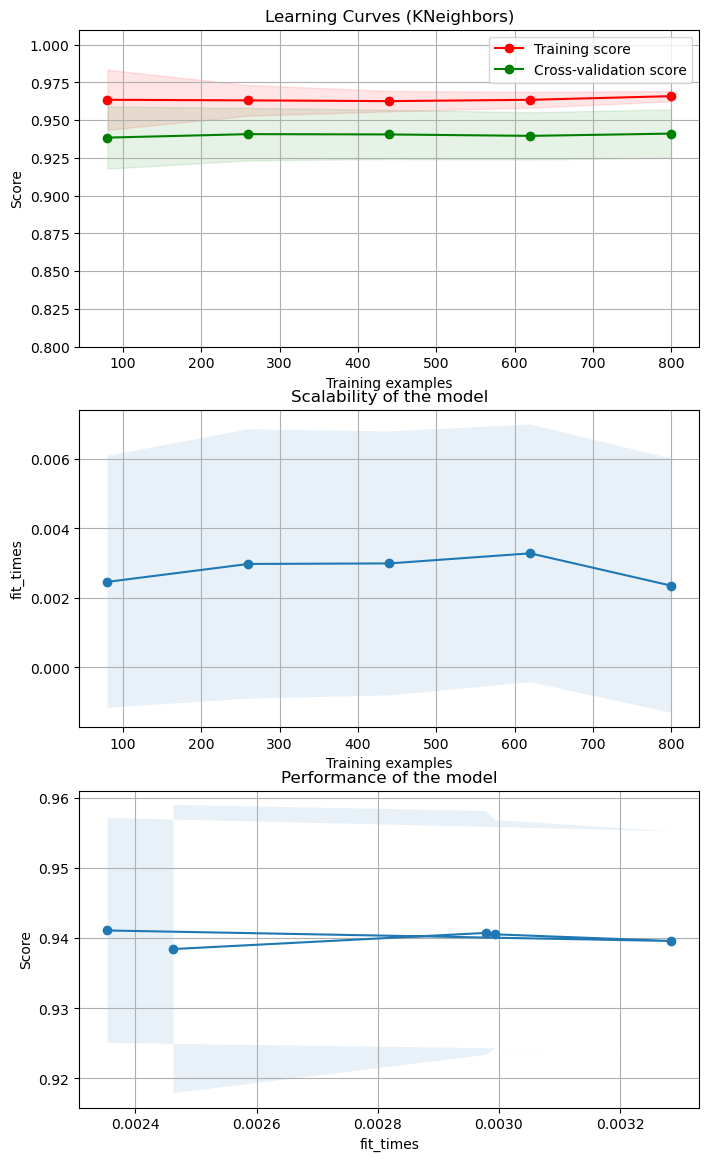

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(8, 14))
title = "Learning Curves (KNeighbors)"
# Cross validation with 100 iterations to get smoother mean test and train
# score curves, each time with 20% data randomly selected as a validation set.
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)

plot_learning_curve(clf_best, title, X_t, y, axes=axes[0:,], ylim=(0.8, 1.01), cv=cv, n_jobs=4)
plt.show()

La planitud en la curva de aprendizaje sugiere que el modelo aprende con muy pocos datos (100 datos ya son suficientes), y solo se encuentra con el error inherente al solapamiento entre las dos distribuciones.

3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.

Intento inducir el overfitting usando un dataset con poco solapamiento (algo de lo que el modelo genere memoria) entre distribuciones pero con muy pocos datos (de modo que el modelo no desarrolla capacidad de generalizar), y el underfitting con muchos datos resultantes de dos distribuciones muy solapadas, de modo que el algoritmo se va aestancar rápidamente en el aprendizaje.

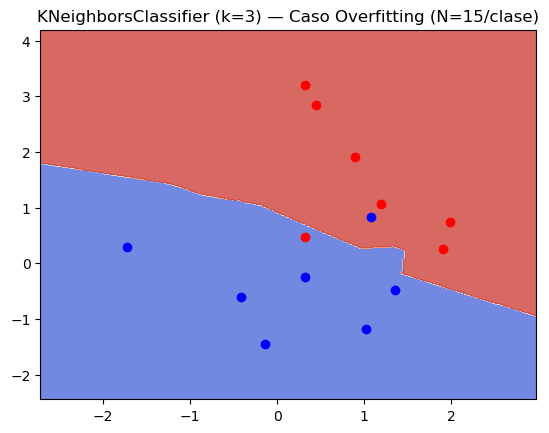

Training error:0.857
Test error: 0.667


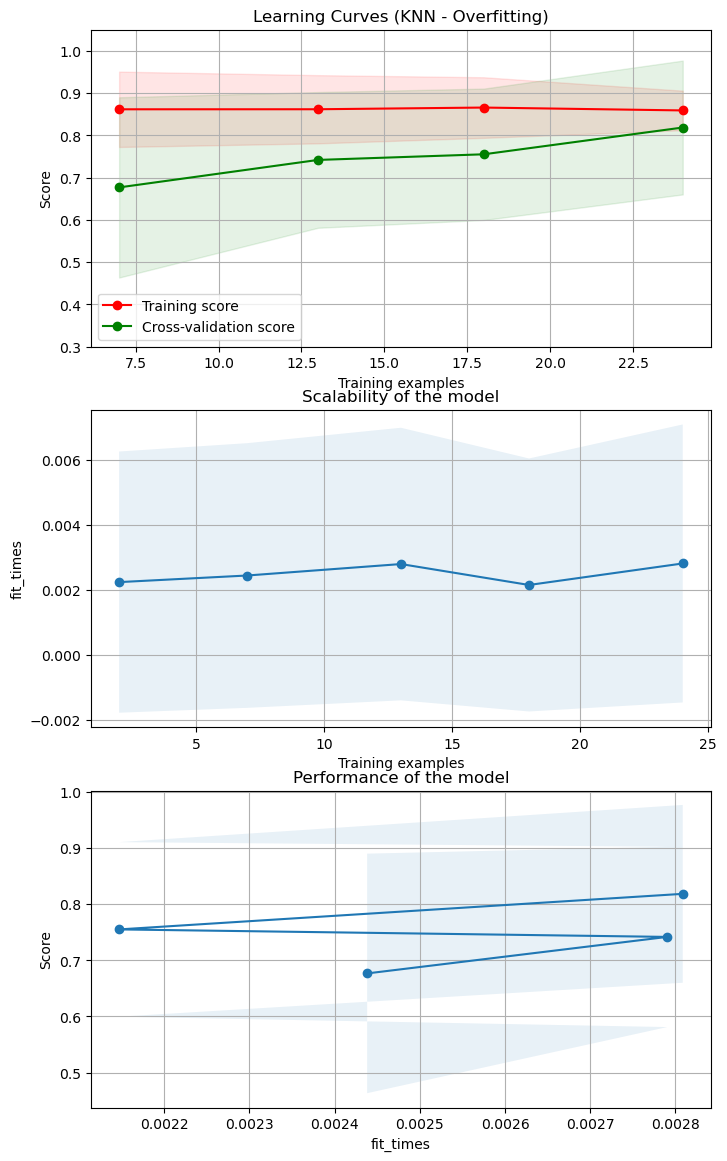

In [46]:
best_knn = 3  # el que ya encontraste como óptimo

#dataset con solpamiento moderad0
rv1_of, rv2_of = data(mu=[0,0], mu1=[1.5,1.5],
                       cov=[[1.0, 0.3], [0.3, 1.0]],
                       cov1=[[1.0, -0.3], [-0.3, 1.0]])
X_of, y_of = sample(15, 15, rv1_of, rv2_of, 3)

X_trainval_of, X_test_of, y_trainval_of, y_test_of = train_test_split(
    X_of, y_of, test_size=0.2, random_state=1, stratify=y_of)
X_train_of, X_val_of, y_train_of, y_val_of = train_test_split(
    X_trainval_of, y_trainval_of, test_size=0.4, random_state=1, stratify=y_trainval_of)

clf_of = KNeighborsClassifier(n_neighbors=best_knn)
clf_of = clf_of.fit(X_train_of, y_train_of)


X0, X1 = X_train_of[:, 0], X_train_of[:, 1]
fig, ax = plt.subplots()
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf_of, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train_of[y_train_of==0][:,0], X_train_of[y_train_of==0][:,1], "bo", alpha=1)
plt.plot(X_train_of[y_train_of==1][:,0], X_train_of[y_train_of==1][:,1], "ro", alpha=1)
plt.title(f"KNeighborsClassifier (k={best_knn}) — Caso Overfitting (N=15/clase)")
plt.show()
print(f"Training error:{clf_of.score(X_train_of, y_train_of):.3f}")
print(f"Test error: {clf_of.score(X_test_of, y_test_of):.3f}")

# curva de aprendizaje
fig, axes = plt.subplots(3, 1, figsize=(8, 14))
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)
plot_learning_curve(clf_of, "Learning Curves (KNN - Overfitting)", X_of, y_of,
                     axes=axes[0:,], ylim=(0.3, 1.05), cv=cv, n_jobs=4)
plt.show()

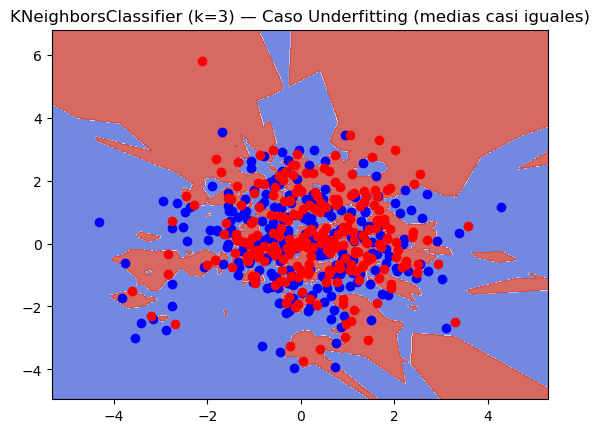

Training error:0.721
Test error: 0.500


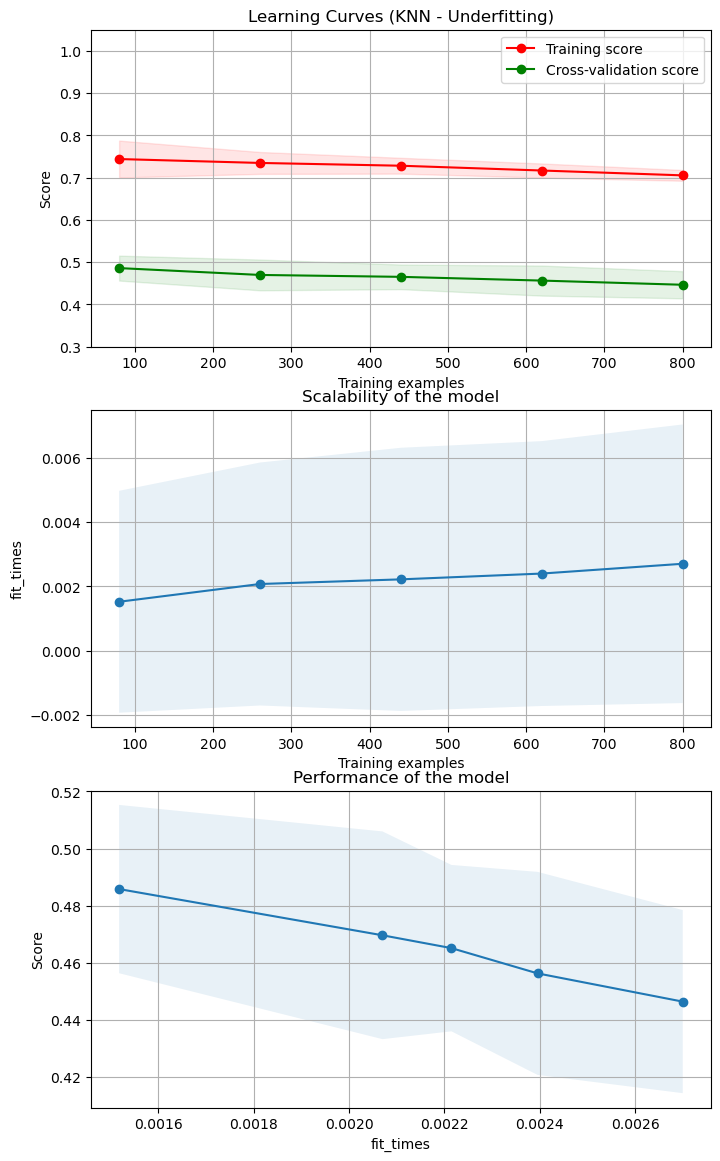

In [47]:
# Dataset con solapamiento extremo
rv1_uf, rv2_uf = data(mu=[0,0], mu1=[0.2,0.2],
                       cov=[[2.0, 0.0], [0.0, 2.0]],
                       cov1=[[2.0, 0.0], [0.0, 2.0]])
X_uf, y_uf = sample(500, 500, rv1_uf, rv2_uf, 1)

X_trainval_uf, X_test_uf, y_trainval_uf, y_test_uf = train_test_split(
    X_uf, y_uf, test_size=0.2, random_state=1, stratify=y_uf)
X_train_uf, X_val_uf, y_train_uf, y_val_uf = train_test_split(
    X_trainval_uf, y_trainval_uf, test_size=0.4, random_state=1, stratify=y_trainval_uf)

clf_uf = KNeighborsClassifier(n_neighbors=best_knn)
clf_uf = clf_uf.fit(X_train_uf, y_train_uf)

X0, X1 = X_train_uf[:, 0], X_train_uf[:, 1]
fig, ax = plt.subplots()
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf_uf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train_uf[y_train_uf==0][:,0], X_train_uf[y_train_uf==0][:,1], "bo", alpha=1)
plt.plot(X_train_uf[y_train_uf==1][:,0], X_train_uf[y_train_uf==1][:,1], "ro", alpha=1)
plt.title(f"KNeighborsClassifier (k={best_knn}) — Caso Underfitting (medias casi iguales)")
plt.show()
print(f"Training error:{clf_uf.score(X_train_uf, y_train_uf):.3f}")
print(f"Test error: {clf_uf.score(X_test_uf, y_test_uf):.3f}")


fig, axes = plt.subplots(3, 1, figsize=(8, 14))
plot_learning_curve(clf_uf, "Learning Curves (KNN - Underfitting)", X_uf, y_uf,
                     axes=axes[0:,], ylim=(0.3, 1.05), cv=cv, n_jobs=4)
plt.show()